In [67]:
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [68]:
# Kaggle House Dataset Download

class KaggleHouse(d2l.DataModule):
    def __init__(
        self,
        batch_size,
        train=None,
        val=None,
    ):
        
        super().__init__()

        self.save_hyperparameters()
        
        # 데이터 셋 다운
        if self.train is None:
            self.raw_train = pd.read_csv(
                d2l.download(
                    d2l.DATA_URL
                    + "kaggle_house_pred_train.csv",
                    self.root,
                    sha1_hash=(
                        "585e9cc93e70b39160e7921475f9bcd7d31219ce"
                    ),
                )
            )
            
            self.raw_val = pd.read_csv(
                d2l.download(
                    d2l.DATA_URL
                    + "kaggle_house_pred_test.csv",
                    self.root,
                    sha1_hash=(
                        "fa19780a7b011d9b009e8bff8e99922a8ee2eb90"
                    ),
                )
            )

In [69]:
# Raw Dataset Shape 확인

data = KaggleHouse(
    batch_size=64,
)

print(
    "training data:",
    data.raw_train.shape,
)

print(
    "test data:",
    data.raw_val.shape,
)

data.raw_train.iloc[
    :4,
    [0, 1, 2, 3, -3, -2, -1],
]

training data: (1460, 81)
test data: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,WD,Normal,208500
1,2,20,RL,80.0,WD,Normal,181500
2,3,60,RL,68.0,WD,Normal,223500
3,4,70,RL,60.0,WD,Abnorml,140000


In [70]:
# raw_train                          raw_val
# (1460, 81)                         (1459, 80)
# Id + 79 features + SalePrice       Id + 79 features
#        │                                  │
#        ├─ Id, SalePrice 제거              ├─ Id 제거
#        ▼                                  ▼
# (1460, 79)                         (1459, 79)
#        └─────────── pd.concat ────────────┘
#                        │
#                        ▼
#               전체 feature table
#                   (2919, 79)
#                        │
#           ┌────────────┴────────────┐
#           ▼                         ▼
#  Numerical feature           Categorical feature
#  standardization              one-hot encoding
#  missing value → 0            missing category도 표시
#           └────────────┬────────────┘
#                        ▼
#               numerical table
#                  (2919, 330)
#                        │
#             1460번째 row에서 분리
#           ┌────────────┴────────────┐
#           ▼                         ▼
#  self.train                   self.val
#  (1460, 330)                  (1459, 330)
#       │
#       └─ SalePrice 추가
#              ▼
#        (1460, 331)

In [71]:
# 셀 5 — Data Preprocessing

def kaggle_house_preprocess(self):
    
    label = "SalePrice"

    # ID와 label을 제외한 train/test feature를 결합한다.
    # 전체 feature table: [2919, 79]
    features = pd.concat(
        (
            # [1460, 81] -> [1460, 79]
            self.raw_train.drop(
                columns=["Id", label]
            ),
            # [1459, 80] -> [1459, 79]
            self.raw_val.drop(
                columns=["Id"]
            ),
        )
    )

    # Numerical feature만 선택.
    # 숫자로 저장된 column 이름만 가져온다
    numeric_features = features.select_dtypes(
        include="number"
    ).columns

    # Mean 0, Variance 1로 standardize한다.
    features[numeric_features] = features[
        numeric_features
    ].apply(
        lambda x: (
            x - x.mean()
        ) / x.std()
    )

    # Numerical missing value를 mean에 해당하는 0으로 채운다.
    features[numeric_features] = features[
        numeric_features
    ].fillna(0)

    # Categorical feature를 one-hot encoding한다.
    features = pd.get_dummies(
        features,
        dummy_na=True,
    )

    # 결합한 feature를 다시 train/test로 분리한다.
    # raw_train.shape[0]: 1460
    num_train = self.raw_train.shape[0]

    self.train = features.iloc[
        :num_train
    ].copy()

    self.train[label] = self.raw_train[
        label
    ].to_numpy()

    self.val = features.iloc[
        num_train:
    ].copy()


KaggleHouse.preprocess = kaggle_house_preprocess

In [72]:
# Preprocessed Dataset Shape 확인

data.preprocess()

print(
    "training data:",
    data.train.shape,
)

print(
    "test data:",
    data.val.shape,
)

training data: (1460, 331)
test data: (1459, 330)


In [73]:
# Log-Price DataLoader 정의

def kaggle_house_get_dataloader(
    self,
    train,
):
    
    label = "SalePrice"
    
    selected_data = (
        self.train
        if train      # (1460, 331)
        else self.val # (1459, 330)
    )
    
    # Kaggle official test data에는 label이 없다.
    if label not in selected_data:
        return None
    
    def dataframe_to_tensor(dataframe):
        return torch.tensor(
            dataframe.to_numpy(
                dtype=float
            ),
            dtype=torch.float32,
        )
        
    # [N, 330]: label 제외
    X = dataframe_to_tensor(
        selected_data.drop(
            columns=[label]
        )
    )
    
    # torch.log -> log price:[N, 1]
    y = torch.log(
        dataframe_to_tensor(
            selected_data[[label]]
        )
    )
    
    # PyTorch DataLoader 생성
    return self.get_tensorloader(
        (X, y),
        train,
    )


KaggleHouse.get_dataloader = (
    kaggle_house_get_dataloader
)

In [74]:
# K-Fold Dataset 생성

def k_fold_data(
    data,
    k,
):
    
    folds = []
    
    # number of data per 1-fold
    fold_size = (
        data.train.shape[0] // k
    )
    
    # 전체 training data: 1460 examples
    # fold size = 292 (K = 5)
    for fold_index in range(k):
        start = (
            fold_index * fold_size
        )
        end = (
            (fold_index + 1) * fold_size
        )

        validation_indices = range(
            start,
            end,
        )
        
        training_fold = data.train.drop(
            index=validation_indices
        )

        validation_fold = data.train.loc[
            validation_indices
        ]
        
#         | `fold_index` | Validation index | Training index |
#         |---:          |---               |---             |
#         | 0            | 0~291            | 나머지          |
#         | 1            | 292~583          | 나머지          |
#         | 2            | 584~875          | 나머지          |
#         | 3            | 876~1167         | 나머지          |
#         | 4            | 1168~1459        | 나머지          |
        folds.append(
            KaggleHouse(
                batch_size=data.batch_size, # 배치 사이즈
                train=training_fold, # 훈련 데이터 셋 인덱스 범위 
                val=validation_fold, # 검증 데이터 셋 인덱스 범위 
            )
        )

    return folds

In [75]:
# K-Fold Cross-Validation

def k_fold(
    trainer,
    data,
    k,
    lr,
):
    validation_losses = []
    models = []

    for fold_index, data_fold in enumerate(
        # 데이터 분할: K 세트의 train/valid 인덱스 반환
        k_fold_data(data, k) 
    ):
        
        # Kth 모델 생성
        model = d2l.LinearRegression(
            lr=lr
        )

        model.board.yscale = "log"

        if fold_index != 0:
            model.board.display = False

        # 하나의 분할 케이스에 대해 epoch 만큼 반복
        trainer.fit(
            model,
            data_fold,
        )

        # 마지막 Validation loss 가져오기
        final_validation_loss = float(
            model.board.data[
                "val_loss"
            ][-1].y
        )

        # 1) Kth validation loss 기록
        validation_losses.append(
            final_validation_loss
        )

        # 2) Kth 모델(파라미터) 저장
        models.append(model)

    # 평균 validation loss 수치 계산
    average_validation_loss = (
        sum(validation_losses)
        / len(validation_losses)
    )

    print(
        "average validation log mse = "
        f"{average_validation_loss}"
    )

    return models

average validation log mse = 0.18276094496250153


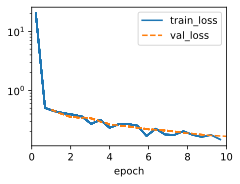

In [76]:
# 셀 11 — Model Selection with K-Fold Cross-Validation

trainer = d2l.Trainer(
    max_epochs=10,
)

models = k_fold(
    trainer,
    data,
    k=5,
    lr=0.01,
)

In [77]:
# Kaggle Submission CSV 생성

test_features = torch.tensor(
    data.val.to_numpy(
        dtype=float
    ),
    dtype=torch.float32,
)

# 모델들을 평가 모드로 바꾸기 (Dropout 등 Off)
for model in models:
    model.eval()

# torch.no_grad(): 
# gradient를 계산하지 않게 해서 메모리를 줄임
with torch.no_grad():
    log_predictions = [
        model(test_features)
        for model in models
    ]

    # [1459, 1] × 5 → [1459, 5]
    stacked_predictions = torch.cat(
        log_predictions,
        dim=1,
    )

    # 1) Log Scale을 원래 price scale로 복원하기 위해 exponential
    # 2) 각각의 샘플에 대해 average 구함 (Ensemble)
    ensemble_predictions = torch.exp(
        stacked_predictions
    ).mean(
        dim=1
    )

submission = pd.DataFrame(
    {
        "Id": data.raw_val["Id"],
        "SalePrice": (
            ensemble_predictions
            .detach()
            .cpu()
            .numpy()
        ),
    }
)

submission.to_csv(
    "submission.csv",
    index=False,
)

submission.head()

,Id,SalePrice
0,1461,82900.562500
1,1462,467192.937500
2,1463,197610.703125
3,1464,268996.031250
4,1465,195385.968750
